# 4.0 Modelling

Trains and tunes the four regression models from the project objectives. Each
model gets its own section below and all of them are scored with the same
`evaluate_model()` helper so Section 5 can compare them like for like.

**Shared Setup must be run first** â€” it rebuilds the leakage-safe train/test
split from Section 3 and defines `XX_train` / `XX_test` / `y_train` / `y_test`
that every model section uses.

## Shared Setup

Reproduces the Section 3.5 pipeline exactly as in `02_data_preparation.ipynb`:
clean → treat outliers → split 80:20 → *then* transform. `transform()` and the
preprocessor are fit on the training split only, so cityname's target
encoding, the one-hot encoder and the scaler never see test data.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

from src.final_dataset_output import build_prepared_dataset, RAW_CSV_PATH
from src.data_transformation import transform, get_engineered_feature_lists, build_preprocessor

# notebooks/ runs with a different cwd than the repo root — adjust the relative path
RAW_CSV_PATH = "../" + RAW_CSV_PATH

prepared_df = build_prepared_dataset(raw_csv_path=RAW_CSV_PATH, verbose=False)

# Split BEFORE any transformation
X = prepared_df.drop(columns=["price"])
y = prepared_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_transformed = transform(X_train)
X_test_transformed = transform(X_test)

numeric, categorical, city = get_engineered_feature_lists(X_train_transformed)

# scale_numeric=True — required by the scale-sensitive models (Linear Regression, KNN).
# Tree-based sections may rebuild the preprocessor with scale_numeric=False.
preprocessor = build_preprocessor(numeric, categorical, city, scale_numeric=True)

# TargetEncoder (used for cityname) is supervised, so fit_transform needs y_train.
XX_train = preprocessor.fit_transform(X_train_transformed, y_train)
XX_test = preprocessor.transform(X_test_transformed)

print("Encoded train:", XX_train.shape)
print("Encoded test :", XX_test.shape)

Encoded train: (79075, 76)
Encoded test : (19769, 76)


---

## KNN Modelling

K-Nearest Neighbours predicts a listing's rent from the mean rent of its most
similar listings in feature space. It is scale-sensitive, so it uses the scaled
matrices built above. `n_neighbors` controls the bias/variance trade-off (small
k = low bias, high variance) and `weights` decides whether closer neighbours
count more, so both are tuned by 5-fold cross-validation.

In [2]:
from src.modelling import train_knn, evaluate_model, to_dense

# KNN has no sparse fast path â€” densify once here and reuse for training and scoring.
XX_train_knn = to_dense(XX_train)
XX_test_knn = to_dense(XX_test)

knn_grid = train_knn(XX_train_knn, y_train, cv=5)

print("Best parameters :", knn_grid.best_params_)
print(f"Best CV RMSE    : ${-knn_grid.best_score_:,.2f}")

Best parameters : {'n_neighbors': 10, 'weights': 'distance'}
Best CV RMSE    : $434.96


**Figure: k vs CV RMSE â€” evidence for hyperparameter search.**
Cross-validated RMSE for every `n_neighbors` tried, with `uniform` and
`distance` weighting shown separately. The minimum of the lower curve is the
selected model.

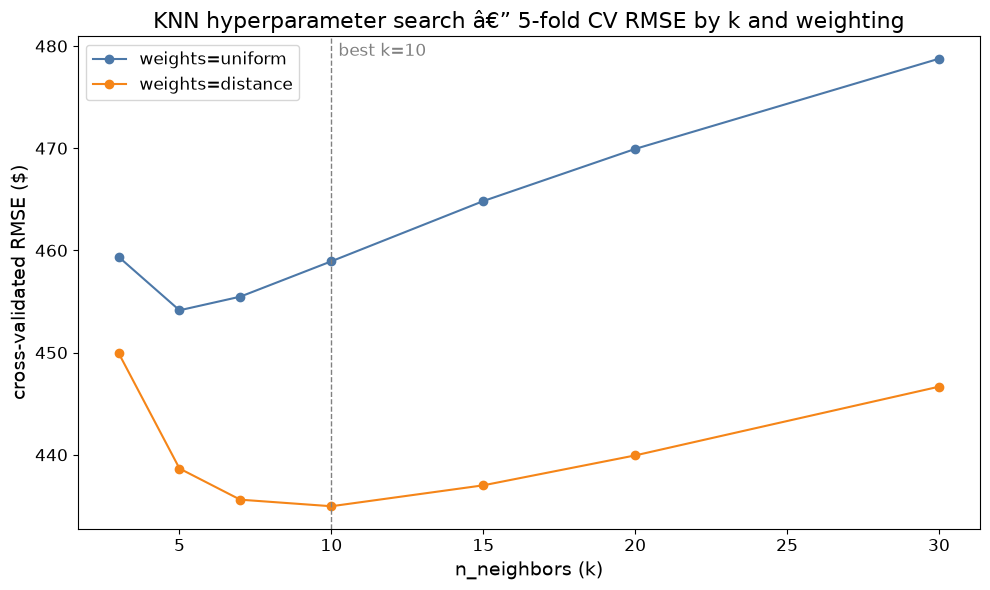

In [3]:
results = knn_grid.cv_results_
fig, ax = plt.subplots(figsize=(10, 6))

for weight, color in [("uniform", "#4C78A8"), ("distance", "#F58518")]:
    mask = np.array(results["param_weights"]) == weight
    ks = np.array(results["param_n_neighbors"])[mask]
    rmse = -np.array(results["mean_test_score"])[mask]
    order = np.argsort(ks)
    ax.plot(ks[order], rmse[order], marker="o", color=color, label=f"weights={weight}")

best_k = knn_grid.best_params_["n_neighbors"]
ax.axvline(best_k, color="grey", linestyle="--", linewidth=1)
ax.annotate(f"best k={best_k}", xy=(best_k, ax.get_ylim()[1]),
            xytext=(5, -14), textcoords="offset points", fontsize=12, color="grey")

ax.set_xlabel("n_neighbors (k)", fontsize=14)
ax.set_ylabel("cross-validated RMSE ($)", fontsize=14)
ax.set_title("KNN hyperparameter search â€” 5-fold CV RMSE by k and weighting", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/knn_k_search.png", dpi=200, bbox_inches="tight")
plt.show()

### Test-set performance

The tuned model is scored once on the held-out 20% test split, which it has not
seen at any point during cleaning, transformation or tuning.

In [4]:
knn_metrics = evaluate_model(knn_grid.best_estimator_, XX_test_knn, y_test)

print(f"RMSE : ${knn_metrics['rmse']:,.2f}")
print(f"MAE  : ${knn_metrics['mae']:,.2f}")
print(f"R2   : {knn_metrics['r2']:.4f}")

RMSE : $458.63
MAE  : $222.13
R2   : 0.7009


**Figure: predicted vs actual price â€” KNN diagnostic.**
Each point is one test listing. The red line is `y = x` (a perfect prediction).
Points below the line are under-predictions; the spread away from the line shows
where the model is least reliable.

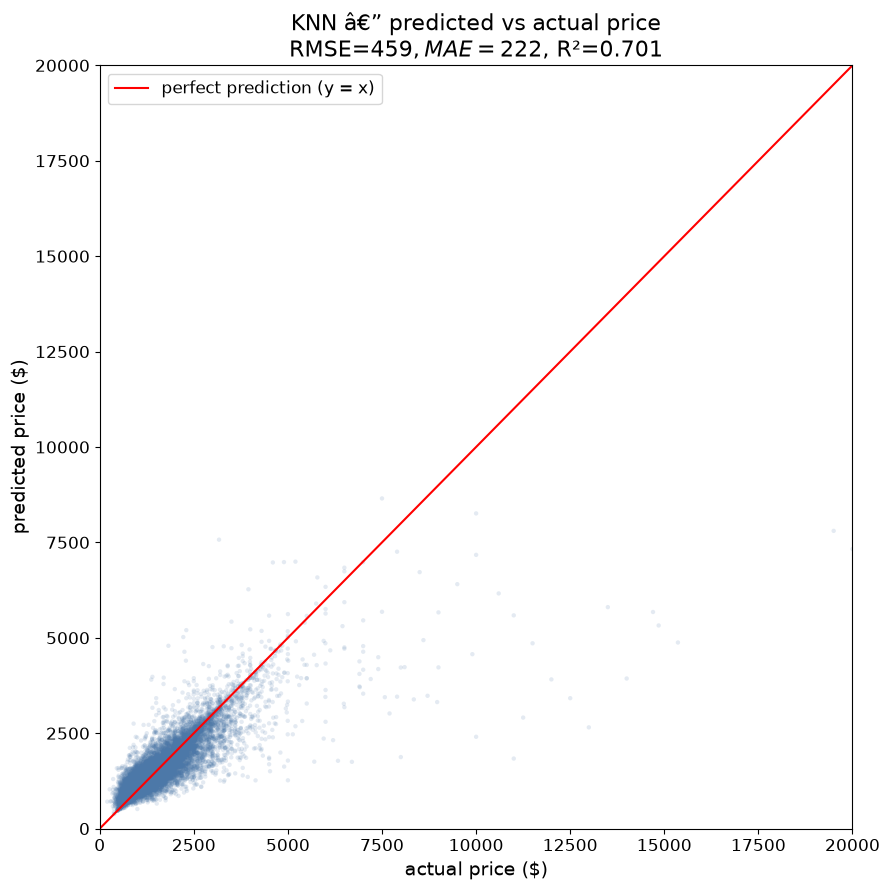

In [5]:
y_pred = knn_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#4C78A8", edgecolors="none")

limits = [0, max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"KNN â€” predicted vs actual price\n"
             f"RMSE=${knn_metrics['rmse']:,.0f}, MAE=${knn_metrics['mae']:,.0f}, "
             f"R\u00b2={knn_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/knn_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()